In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

Employee Attrition Prediction:
Problem Statement: Predict whether an employee leaves the company or not(attrition of the employee)  by understanding the underlying patterns that are associated with the attrition using the provided dataset.
(It is a Binary Classification Task where the output is (Yes/No) type)

Objective: 
The main objective of this project is to build a machine learning model to predict employee attrition using employee-related features, helping the HR department identify patterns associated with attrition and support workforce planning and appropriate retention strategies.

1.Load the dataset

In [4]:
data=pd.read_csv("../WA_Fn-UseC_-HR-Employee-Attrition.csv")

Understand the dataset structure

In [5]:
data.shape


(1470, 35)

In [6]:
data.size

51450

In [7]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [9]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


Know how many categorical columns in dataset

In [10]:
data.select_dtypes(include="object").shape[1]

C:\Users\msssi\AppData\Local\Temp\ipykernel_19916\1666300180.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include="object").shape[1]


9

so we need to convert these 9 columns to numeric form (encode) since model works only on numeric data. We may also not include them in training process if they are not necessary(Ex:An identifier column)

know how many numerical columns are present in dataset

In [11]:
data.select_dtypes(include="number").shape[1]

26

DATA VALIDATION

Missing values

In [12]:
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

overall count of missing values

In [13]:
data.isnull().sum().sum()

np.int64(0)

Finding the columns that are categorical and storing their names as a list

In [14]:
obj_col=data.select_dtypes(include="object").columns

C:\Users\msssi\AppData\Local\Temp\ipykernel_19916\4234558324.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_col=data.select_dtypes(include="object").columns


Sometimes .isna() might show 0 missing values but categorical columns might have empty strings or whitespaces which are also considered as missing values. So find the count of these empty strings/whitespaces

In [15]:
(data[obj_col].apply(lambda col:col.str.strip()=="")).sum()

Attrition         0
BusinessTravel    0
Department        0
EducationField    0
Gender            0
JobRole           0
MaritalStatus     0
Over18            0
OverTime          0
dtype: int64

Stastical summary of numerical columns(Data Validation-(see min and max values if they have valid ranges or not))

In [16]:
#missing_percentage=(data.isnull().mean())*100
#Is the missingness random?
#Why might they be missing? here i dont have any missing values

In [17]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


The numerical features were inspected using descriptive statistics. No obviously invalid negative values or extreme ranges were observed based on the expected meaning of the variables

Know the categories of each categorical column

In [18]:
for col in obj_col:
    print(f"{col}:{list(data[col].unique())}")

Attrition:['Yes', 'No']
BusinessTravel:['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Department:['Sales', 'Research & Development', 'Human Resources']
EducationField:['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
Gender:['Female', 'Male']
JobRole:['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
MaritalStatus:['Single', 'Married', 'Divorced']
Over18:['Y']
OverTime:['Yes', 'No']


A feature with only one unique value provides no information for distinguishing one employee from another.
there's nothing useful to learn from that feature.

This is called a constant feature or a zero-variance feature.
so we would not consider this over18 column in our feature set

know how many samples belong to a particular category- value_counts()

tells us the distribution of that categorical feature

In [19]:
for col in obj_col:
    print(f"{data[col].value_counts()}")
    print()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

Over18
Y    1470
Name:

Checking Duplicates

In [20]:
data.duplicated().sum()

np.int64(0)

Data Validation Summary: The dataset contains 1,470 employee records and 35 columns. No null values, empty strings, or duplicate records were detected. Numerical features did not show obviously invalid ranges, and categorical variables contained consistent values. The Over18 feature was identified as a constant feature because all observations have the value Y, making it a potential candidate for removal during feature selection.

EDA

In [21]:
data.nunique(axis=0)

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

EmployeeCount,Over18,StandardHours are having only 1 value. So they are useless as variance is 0.

In [22]:
data.select_dtypes(include="object").apply(lambda x:x.str.strip().eq("").sum())

C:\Users\msssi\AppData\Local\Temp\ipykernel_19916\730475627.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include="object").apply(lambda x:x.str.strip().eq("").sum())


Attrition         0
BusinessTravel    0
Department        0
EducationField    0
Gender            0
JobRole           0
MaritalStatus     0
Over18            0
OverTime          0
dtype: int64

In [23]:
#x.str.strip() targets cells: The .str prefix tells pandas to look inside the Series container and apply the strip operation to every individual cell element-by-element.

#.eq("") creates a Boolean mask: It checks every cell individually. It yields a Series of True or False values matching the original row length (e.g., [False, True, False]).
#x.str.strip().eq("") outputs a pandas Series:Pandas objects are highly specialized. When you perform an operation using .str or .eq(), pandas keeps the data wrapped inside a Series container (looks like a column with index numbers).Pandas Series do have a .sum() method:Unlike a standard Python list, the pandas library explicitly built a .sum() method directly into the Series object.
#When you call .sum() on a pandas boolean Series, pandas automatically treats True as 1 and False as 0 behind the scenes, giving you the correct total count.

In [24]:
numerical_cols = [
    'Age','DailyRate','DistanceFromHome','HourlyRate',
    'MonthlyIncome','MonthlyRate','NumCompaniesWorked',
    'PercentSalaryHike','TotalWorkingYears',
    'TrainingTimesLastYear','YearsAtCompany',
    'YearsInCurrentRole','YearsSinceLastPromotion',
    'YearsWithCurrManager']
data[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.0,14235.5,20461.50,26999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.00,9.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.00,25.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.00,40.0
TrainingTimesLastYear,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.00,6.0


In [25]:
potential_outliers=[
"MonthlyIncome",
"NumCompaniesWorked",	
"TotalWorkingYears","YearsAtCompany","YearsInCurrentRole",
"YearsSinceLastPromotion","YearsWithCurrManager"]

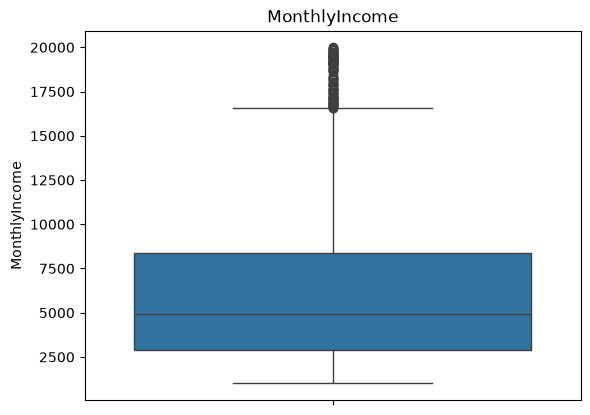

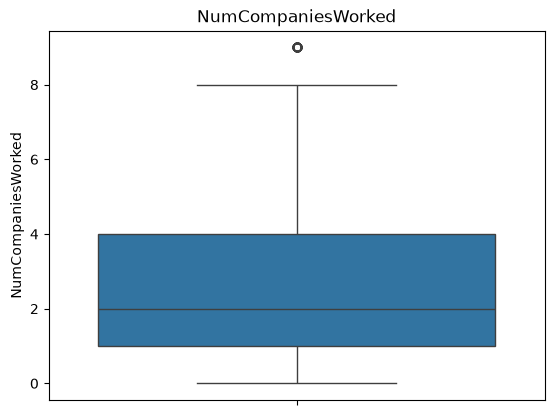

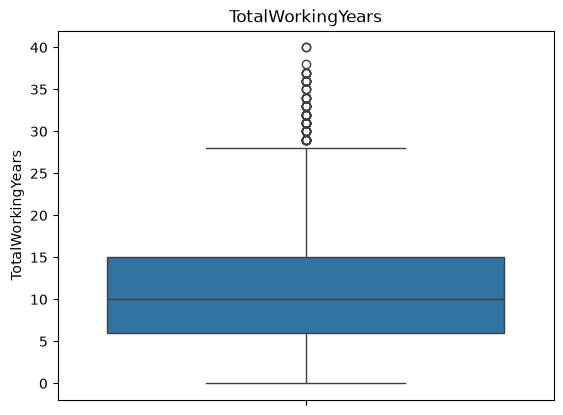

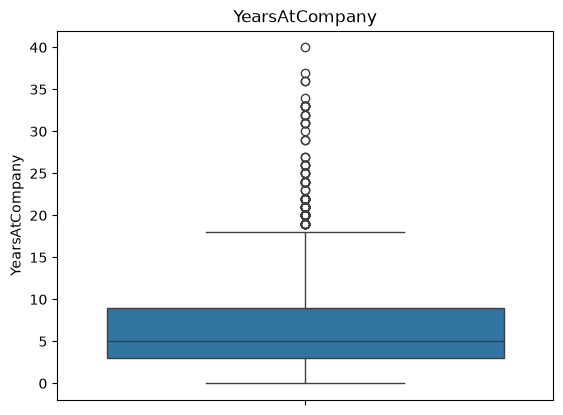

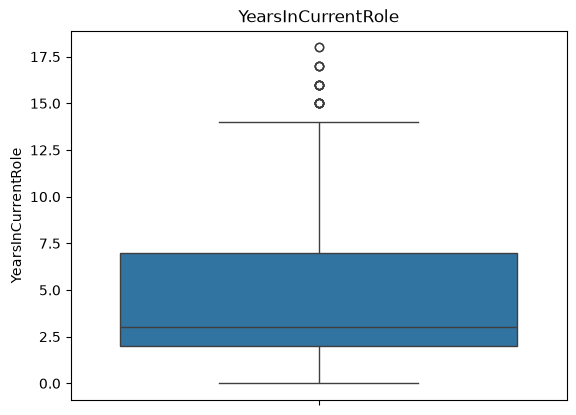

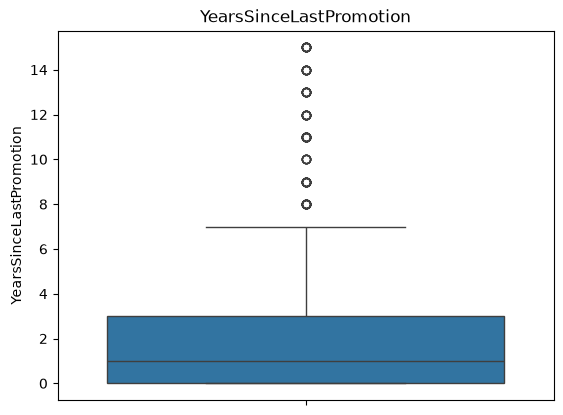

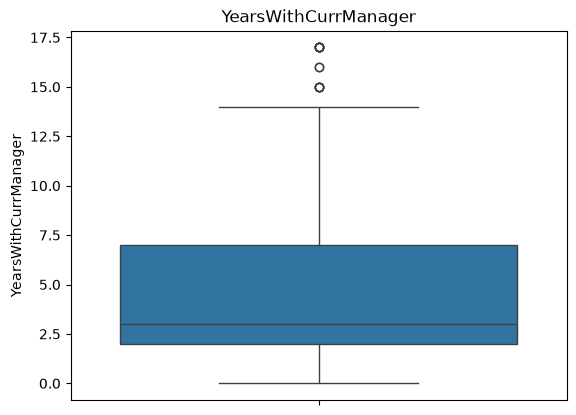

In [26]:
for col in potential_outliers:
    plt.figure()
    sns.boxplot(data[col])
    plt.title(col)
    plt.show()
    


all of the assumed columns have outliers. Let us plot for all remaining numeric columns this time

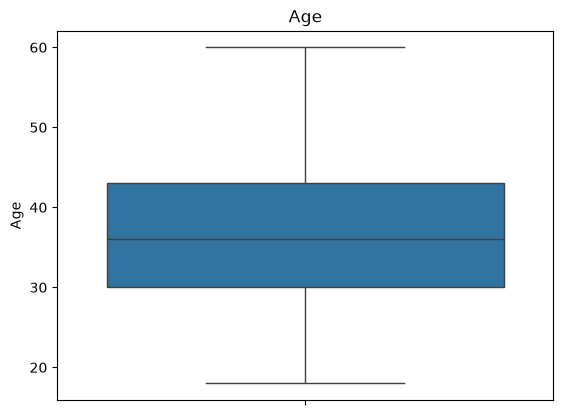

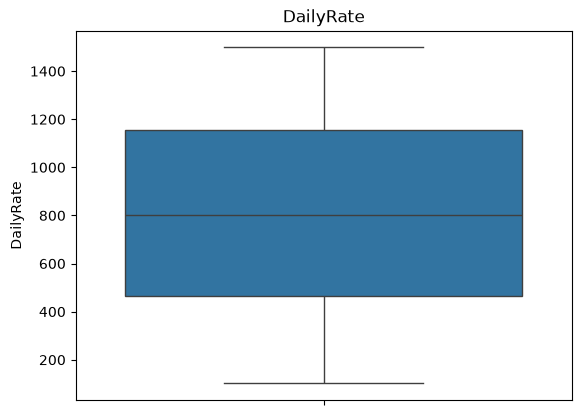

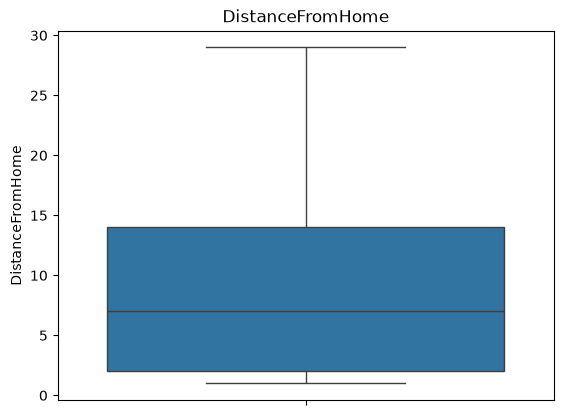

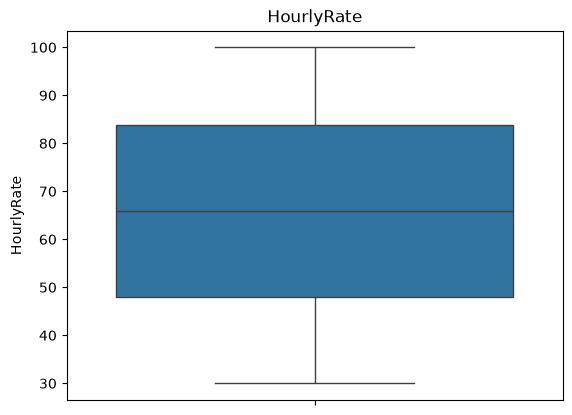

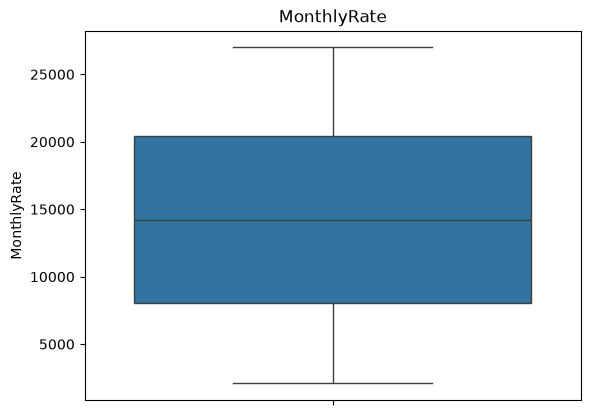

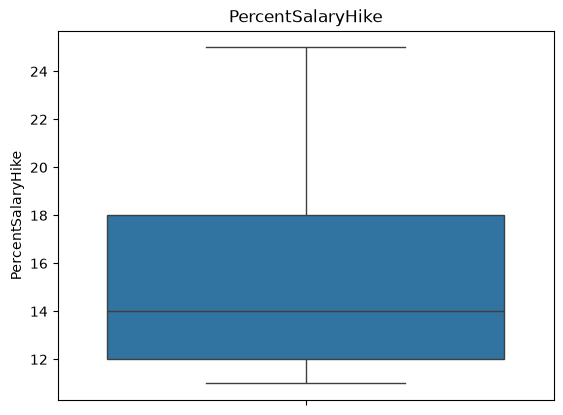

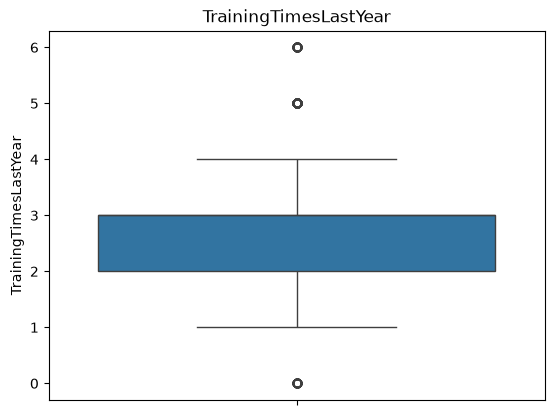

In [27]:
for col in numerical_cols:
    if col not in potential_outliers:
        plt.figure()
        sns.boxplot(data[col])
        plt.title(col)
        plt.show()

So from the above box plots, TrainingTimesLastYear, MonthlyIncome,
NumCompaniesWorked,	 TotalWorkingYears, YearsAtCompany,YearsInCurrentRole, YearsSinceLastPromotion,YearsWithCurrManager are having outliers

Understanding the distribution of categorical features

In [28]:
for col in obj_col:
    print("\n")
    print(data[col].value_counts(normalize=True)*100)



Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


BusinessTravel
Travel_Rarely        70.952381
Travel_Frequently    18.843537
Non-Travel           10.204082
Name: proportion, dtype: float64


Department
Research & Development    65.374150
Sales                     30.340136
Human Resources            4.285714
Name: proportion, dtype: float64


EducationField
Life Sciences       41.224490
Medical             31.564626
Marketing           10.816327
Technical Degree     8.979592
Other                5.578231
Human Resources      1.836735
Name: proportion, dtype: float64


Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64


JobRole
Sales Executive              22.176871
Research Scientist           19.863946
Laboratory Technician        17.619048
Manufacturing Director        9.863946
Healthcare Representative     8.911565
Manager                       6.938776
Sales Representative          5.646259
Research Director             5.442177


In [29]:
ordinal_cols = [
    'Education',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobLevel',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'WorkLifeBalance',
    'PerformanceRating'
]

Understanding the distribution of ordinal features

In [30]:
for col in ordinal_cols:
    print("\n")
    print((data[col].value_counts(normalize=True)*100).sort_index())



Education
1    11.564626
2    19.183673
3    38.911565
4    27.074830
5     3.265306
Name: proportion, dtype: float64


EnvironmentSatisfaction
1    19.319728
2    19.523810
3    30.816327
4    30.340136
Name: proportion, dtype: float64


JobInvolvement
1     5.646259
2    25.510204
3    59.047619
4     9.795918
Name: proportion, dtype: float64


JobLevel
1    36.938776
2    36.326531
3    14.829932
4     7.210884
5     4.693878
Name: proportion, dtype: float64


JobSatisfaction
1    19.659864
2    19.047619
3    30.068027
4    31.224490
Name: proportion, dtype: float64


RelationshipSatisfaction
1    18.775510
2    20.612245
3    31.224490
4    29.387755
Name: proportion, dtype: float64


StockOptionLevel
0    42.925170
1    40.544218
2    10.748299
3     5.782313
Name: proportion, dtype: float64


WorkLifeBalance
1     5.442177
2    23.401361
3    60.748299
4    10.408163
Name: proportion, dtype: float64


PerformanceRating
3    84.62585
4    15.37415
Name: proportion, dtype: float

Analysing if target class is balanced/imbalanced

In [31]:
data["Attrition"].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

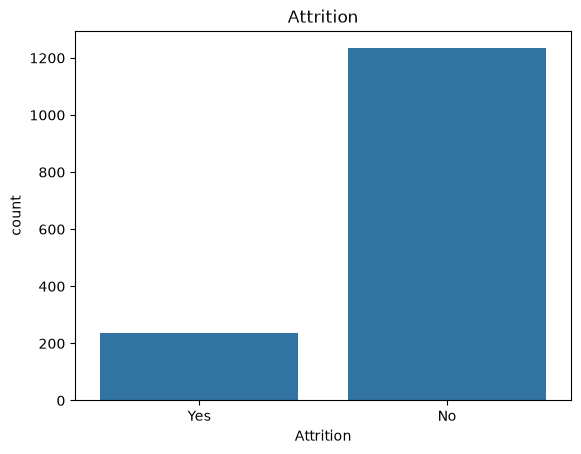

In [32]:
plt.figure()
sns.countplot(data=data,x="Attrition")
plt.title("Attrition")
plt.show()

Around 16.1% of employees are associated with Attrition where as 83.8% employees stayed.

#categorical columns vs target analysis

In [35]:
pd.crosstab(data["OverTime"],data["Attrition"],normalize=True)*100

Attrition,No,Yes
OverTime,,
No,64.217687,7.482993
Yes,19.659864,8.639456


In [46]:
for col in obj_col:
    if col=="Attrition":
        continue
    print()
    print(pd.crosstab(data[col],data["Attrition"],normalize=True)["Yes"]*100)


BusinessTravel
Non-Travel            0.816327
Travel_Frequently     4.693878
Travel_Rarely        10.612245
Name: Yes, dtype: float64

Department
Human Resources           0.816327
Research & Development    9.047619
Sales                     6.258503
Name: Yes, dtype: float64

EducationField
Human Resources     0.476190
Life Sciences       6.054422
Marketing           2.380952
Medical             4.285714
Other               0.748299
Technical Degree    2.176871
Name: Yes, dtype: float64

Gender
Female     5.918367
Male      10.204082
Name: Yes, dtype: float64

JobRole
Healthcare Representative    0.612245
Human Resources              0.816327
Laboratory Technician        4.217687
Manager                      0.340136
Manufacturing Director       0.680272
Research Director            0.136054
Research Scientist           3.197279
Sales Executive              3.877551
Sales Representative         2.244898
Name: Yes, dtype: float64

MaritalStatus
Divorced    2.244898
Married     5.71428

The categories "Travel_rarely, R&D, Lifesciences, Male, Laboratory Technician, Single(Marital Status), who does overtime" have been associated with higher observed attrition rates than the other categories of same respective features

ordinal columns vs target analysis

In [47]:
for col in ordinal_cols:
    
    print()
    print(pd.crosstab(data[col],data["Attrition"],normalize=True)["Yes"]*100)


Education
1    2.108844
2    2.993197
3    6.734694
4    3.945578
5    0.340136
Name: Yes, dtype: float64

EnvironmentSatisfaction
1    4.897959
2    2.925170
3    4.217687
4    4.081633
Name: Yes, dtype: float64

JobInvolvement
1    1.904762
2    4.829932
3    8.503401
4    0.884354
Name: Yes, dtype: float64

JobLevel
1    9.727891
2    3.537415
3    2.176871
4    0.340136
5    0.340136
Name: Yes, dtype: float64

JobSatisfaction
1    4.489796
2    3.129252
3    4.965986
4    3.537415
Name: Yes, dtype: float64

RelationshipSatisfaction
1    3.877551
2    3.061224
3    4.829932
4    4.353741
Name: Yes, dtype: float64

StockOptionLevel
0    10.476190
1     3.809524
2     0.816327
3     1.020408
Name: Yes, dtype: float64

WorkLifeBalance
1    1.700680
2    3.945578
3    8.639456
4    1.836735
Name: Yes, dtype: float64

PerformanceRating
3    13.605442
4     2.517007
Name: Yes, dtype: float64


JobLevel,StockOptionLevel,Performance Rating are showing a monotonic relationship with target


In [49]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data["Attrition"]=le.fit_transform(data["Attrition"])
data.head()



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


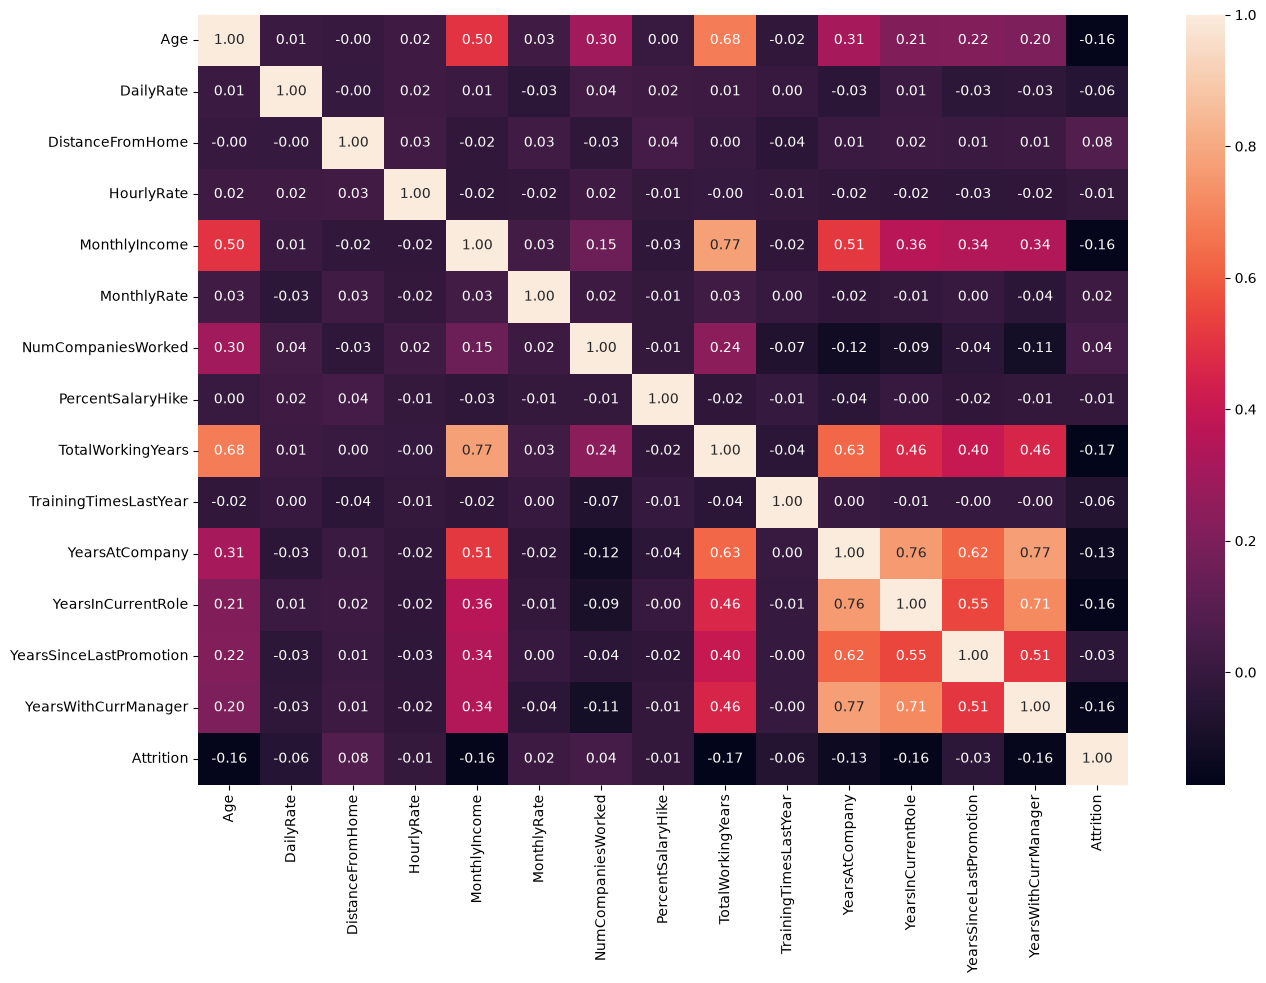

In [51]:
corr_data=data[numerical_cols]
corr_data["Attrition"]=data["Attrition"]
corr=corr_data.corr()
plt.figure(figsize=(15,10))

sns.heatmap(corr,annot=True,fmt='.2f')
plt.show()

Data Preprocessing and Feature selection

In [52]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [ ]:
x=data.drop(columns=["Attrition","EmployeeCount","EmployeeNumber","Over18","StandardHours"])


In [57]:
y=data["Attrition"]

In [58]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42,shuffle=True)
#shuffle helps to generalize the model but you should not shuffle in case of time series and when the order of samples matter


In [ ]:
from sklearn.preprocessing import OneHotEncoder
oe=OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False)

oe.fit(x_train[obj_col])
x_train_encoded=oe.transform(x_train[obj_col])
x_test_encoded=oe.transform(x_test[obj_col])

print(oe.get_feature_names_out(obj_col))
print(oe.get_feature_names_out())



In [ ]:
df_train_encode=pd.DataFrame(x_train_encoded,columns=oe.get_feature_names_out(obj_col),index=x_train.index)
df_test_encode=pd.DataFrame(x_test_encoded,columns=oe.get_feature_names_out(obj_col),index=x_test.index)
x_train=pd.concat([x_train.drop(columns=obj_col),df_train_encode],axis=1)
x_test=pd.concat([x_test.drop(columns=obj_col),df_test_encode],axis=1)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train[numerical_cols]=scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols]=scaler.transform(x_test[numerical_cols])